# Self-avoiding walk

Here we implement a self-avoiding walk. We use `n` walkers with `n-1` bonds in a 2-d lattice. 

This is a (*very bad*) brute force approach where we allow `n` walkers to walk, and just discard collisions. It is extremely intractible as discussed in lecture. 

In [1]:
! swig -c++ -python swig/sawalk.i
! python swig/setup_sawalk.py build_ext --inplace

sawalk.cpp: In member function ‘void SAWalk::run()’:
sawalk.cpp:14:16: warning: comparison of integer expressions of different signedness: ‘int’ and ‘unsigned int’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wsign-compare-Wsign-compare]8;;]
   14 |   while (walks < n_walks) {
      |          ~~~~~~^~~~~~~~~
sawalk.cpp:23:29: warning: comparison of integer expressions of different signedness: ‘int’ and ‘unsigned int’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wsign-compare-Wsign-compare]8;;]
   23 |     for (int step = 0; step < n_steps; step++) {
      |                        ~~~~~^~~~~~~~~
sawalk.cpp:34:25: warning: comparison of integer expressions of different signedness: ‘int’ and ‘std::vector<Site>::size_type’ {aka ‘long unsigned int’} []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wsign-compare-Wsign-compare]8;;]
   34 |       for (int i = 0; i < sites.size(); i++) {
      |                       ~~^

In [2]:
import sys
import os
sys.path.append( os.path.abspath("swig") )

In [3]:
import sawalk
import numpy as np
import matplotlib.pyplot as plt
import time


In [4]:
n_steps = 10
n_walks = 10
s = sawalk.SAWalk(n_steps, n_walks)
s.run()
r2av = s.get_r2av()
r4av = s.get_r4av()
stdDev = s.get_stdDev()
totalWalks = s.get_walks() + s.get_failed_walks()
failedPercent = s.get_failed_walks() / totalWalks
print( " Mean square distance <r^2> = " , r2av , "\n"
         , " Standard deviation         = " , stdDev , "\n"
         , " Percentage failed walks    = " , failedPercent)

 Mean square distance <r^2> =  32.8 
  Standard deviation         =  15.39350512391509 
  Percentage failed walks    =  0.9290780141843972


In [5]:
n_arr = np.arange(1, 50, dtype=int)
fail_percents = np.zeros_like(n_arr, dtype=float)
times = np.zeros_like(n_arr, dtype=float)

def run_sawalk(n):
    s = sawalk.SAWalk(n, 20) # swig doesn't understand numpy data types
    s.run()
    return s.get_failed_walks() / (s.get_walks() + s.get_failed_walks())
    
for i, n in enumerate(n_arr):
    if n % 5 == 0:
        print(f"{n} / {np.max(n_arr)}")
    t1 = time.time()
    fail_percents[i] = run_sawalk(int(n))
    t2 = time.time()
    times[i] = t2 - t1
print("Done")

5 / 49
10 / 49
15 / 49
20 / 49
25 / 49
30 / 49
35 / 49
40 / 49
45 / 49
Done


[0.         0.35483871 0.375      0.66101695 0.70149254 0.78723404
 0.74025974 0.88372093 0.87096774 0.93006993 0.95073892 0.95670996
 0.96343693 0.97938144 0.98289136 0.98927614 0.99092147 0.99368288
 0.99451454 0.99772469 0.99842829 0.99787302 0.99917081 0.99883923
 0.99949199 0.99955419 0.9996656  0.99973613 0.99975507 0.99989938
 0.99989621 0.99995851 0.99993178 0.99996539 0.99997067 0.99997612
 0.99998826 0.99998895 0.99999498 0.99999611 0.9999946  0.99999707
 0.99999782 0.99999788 0.999999   0.9999995  0.99999933 0.99999966
 0.99999968]


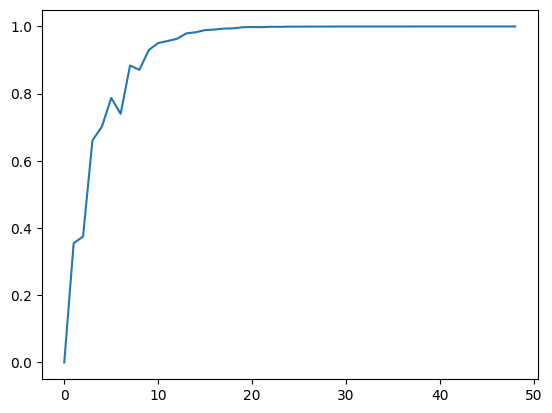

In [6]:
print(fail_percents)
plt.plot(fail_percents)

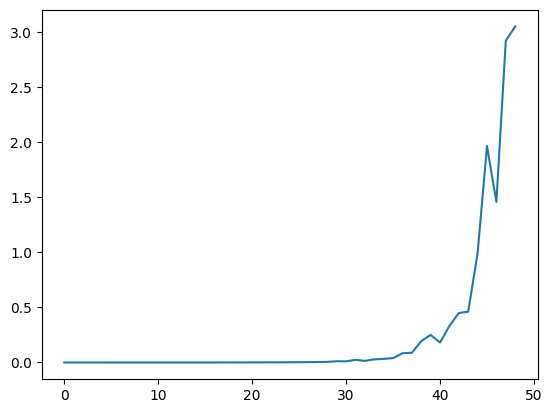

In [7]:
plt.plot(times)